In [ ]:
!pip install tensorflow

^C


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\laila\\AppData\\Roaming\\Python\\Python313\\Scripts\\saved_model_cli.exe' -> 'C:\\Users\\laila\\AppData\\Roaming\\Python\\Python313\\Scripts\\saved_model_cli.exe.deleteme'
Check the permissions.



Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.80.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using c

In [4]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl (351.2 MB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Load Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 14s 1us/step


# Check Shape of Dataset

In [3]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


# Display Sample Image

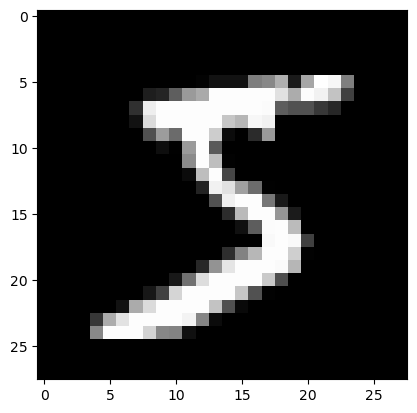

Digit: 5


In [13]:
# Display first image from dataset

plt.imshow(x_train[0], cmap='gray')

# Show image
plt.show()

# Print corresponding digit
print("Digit:", y_train[0])

# Normalize Data


In [5]:
# Normalize pixel values between 0 and 1

x_train = x_train / 255.0
x_test = x_test / 255.0

# Build Neural Network Model

In [6]:
# Create neural network model

model = keras.Sequential([

    # Convert 2D image into 1D array
    keras.layers.Flatten(input_shape=(28,28)),

    # Hidden layer with 128 neurons
    keras.layers.Dense(128, activation='relu'),

    # Output layer with 10 neurons (digits 0-9)
    keras.layers.Dense(10, activation='softmax')

])

C:\Users\laila\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Compile Model

In [7]:
# Compile the model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model

In [8]:
# Train neural network model

model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9258 - loss: 0.2592
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9667 - loss: 0.1142
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9761 - loss: 0.0790
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9817 - loss: 0.0591
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9862 - loss: 0.0449


# Evaluate Model

In [9]:
# Evaluate accuracy using test data

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Accuracy:", test_acc * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9766 - loss: 0.0766
Accuracy: 97.65999913215637


# Predict Digit

In [10]:
# Predict digits using test data

prediction = model.predict(x_test)

# Print predicted digit
print("Predicted Digit:", prediction[0].argmax())

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted Digit: 7


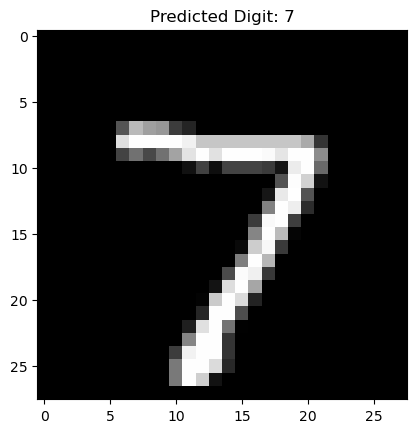

In [11]:
# Display predicted image

plt.imshow(x_test[0], cmap='gray')

plt.title(f"Predicted Digit: {prediction[0].argmax()}")

plt.show()